# Natural Language Processing in Engineering
A structured narrative for a combined lecture + coding notebook.

Natural Language Processing (NLP) enables computers to understand, interpret, and generate human language. There are three fundamental reasons why computers perform NLP: **first**, to communicate with humans in natural, intuitive ways; **second**, to learn from vast amounts of textual information; and **third**, to advance scientific understanding of language itself by combining AI tools with linguistics, cognitive psychology, and neuroscience.

NLP is far from a new field. Its roots trace back to 1949, when Claude Shannon and Warren Weaver developed the first N-gram word model in English, laying the groundwork for statistical language processing. The journey continued with the Bag-of-Words model (1954), Latent Semantic Indexing (LSI, 1990), and Latent Dirichlet Allocation (LDA, 2002). Information extraction gained momentum through the Annual Message Understanding Conferences (MUC) sponsored by the US government starting in 1997. The deep learning revolution brought word embeddings (Word2Vec, 2013), recurrent neural networks, LSTMs, and GRU units. A paradigm shift occurred in 2017 with the landmark paper "Attention Is All You Need," introducing transformers. Most recently, in 2024, DeepSeek published technical reports on reasoning models trained through reinforcement learning, pushing the boundaries further.

```mermaid
timeline
    title Evolution of Natural Language Processing
    1949 : N-gram Models (Shannon & Weaver)
    1954 : Bag-of-Words
    1990 : Latent Semantic Indexing (LSI)
    1997 : Message Understanding Conferences (MUC)
    2002 : Latent Dirichlet Allocation (LDA)
    2013 : Word2Vec & Embeddings
    2014-2016 : RNNs, LSTMs, GRUs
    2017 : Transformers ("Attention Is All You Need")
    2024 : Reasoning Models (DeepSeek)
``` 

## 1. Introduction
### 1.1 Why Engineering Generates Text

Engineers work in a world saturated with unstructured text. Every day, technicians write maintenance logs describing equipment behavior, managers draft shift reports, customers submit warranty claims and feedback, and design teams produce documentation. But text doesn't just flow outward from engineering—it surrounds engineers at every turn.

Consider the typical engineering environment: **standards and specifications** define what must be built; **Standard Operating Procedures (SOPs)** dictate how work is done; **meeting transcripts** with clients or management capture requirements and constraints. Engineers examine **prototype test reports**, analyze **customer complaints**, and study **patent documents**—which serve as blueprints for problem-solving across industries. Technical documentation holds decades of institutional knowledge about failure modes, design decisions, and successful solutions.

This wealth of textual information presents both an opportunity and a challenge. NLP enables engineers to:
- Automatically process and categorize maintenance logs
- Extract insights from customer feedback at scale
- Search vast technical archives for relevant precedents
- Interface with engineering tools using natural language
- Convert speech to text for hands-free documentation

```mermaid
graph TD
    A[Engineering Text Sources] --> B[Internal Sources]
    A --> C[External Sources]
    A --> D[Documentation]

    B --> B1[Maintenance Logs]
    B --> B2[Shift Reports]
    B --> B3[Meeting Transcripts]
    B --> B4[Test Reports]

    C --> C1[Customer Feedback]
    C --> C2[Warranty Claims]
    C --> C3[Complaint Forms]
    C --> C4[Patent Documents]

    D --> D1[Standards & Specs]
    D --> D2[SOPs]
    D --> D3[Design Documentation]
    D --> D4[Technical Manuals]
```

### 1.2 NLP in the Engineering Workflow

NLP has become an essential component of modern engineering decision support systems. Rather than manually sifting through thousands of maintenance logs or customer reviews, engineers can leverage NLP to extract patterns, identify recurring failures, and prioritize issues based on severity and frequency.

**Typical engineering applications of NLP include:**

- **Fault detection and diagnostics**: Automatically analyzing technician logs to identify equipment problems before they escalate
- **Customer feedback mining**: Processing reviews and complaints to discover design weaknesses or feature requests
- **Documentation retrieval**: Searching technical manuals and historical records using semantic similarity rather than exact keyword matches
- **Automated reporting**: Generating summaries of preventive maintenance activities
- **Voice interfaces**: Using speech-to-text to document findings hands-free in the field, and text-to-speech for accessibility

Traditional keyword-based search falls short when engineers need to find conceptually similar failures or when terminology varies across teams. **Embedding-based search**—which we'll explore in depth—enables finding semantically related content even when different words are used. For example, searching for "bearing vibration" might surface logs about "shaft oscillation" or "rotor imbalance" because these concepts are closely related in meaning.

## 2. Why Natural Language Is Hard

Natural language is fundamentally challenging for computers because it evolved for human communication, not machine processing. Unlike programming languages with strict syntax and unambiguous meaning, human language is messy, context-dependent, and full of implicit knowledge. For engineering applications, these challenges are amplified by technical jargon, abbreviated notation, and the informal style of field documentation.

**Ambiguity and Polysemy**: Words often have multiple meanings depending on context. In engineering, the word "bearing" could refer to a mechanical component, a directional measurement, or load-carrying capacity. "Seal" might mean a gasket or a coating. "Crack" could describe a fracture, an audible sound, or the act of solving a problem. Without context, machines struggle to determine which meaning applies.

**Pragmatics and Technician Shorthand**: Field technicians rarely write in complete sentences. A maintenance log might read "pump #3 loud, checked brgs OK, poss cavitation" — abbreviated, informal, and requiring domain knowledge to interpret. The meaning depends not just on the words, but on shared understanding of maintenance procedures and equipment behavior.

**Quantification, Tense, and Modality**: Engineering language is full of vague quantifiers and uncertainty. Phrases like "slightly higher temperature," "noticeable vibration," or "might fail soon" are subjective and context-dependent. What counts as "slightly higher" depends on normal operating conditions. "Might fail" expresses uncertainty about future events. Temporal references like "checked yesterday" or "has been running hot since Tuesday" require tracking time and relating events chronologically.

**Long-Distance Dependencies**: In technical writing, cause-and-effect relationships often span multiple sentences or even paragraphs. A technician might describe symptoms in one sentence, actions taken in another, and outcomes in a third. Understanding requires connecting information across the entire narrative: "Motor was overheating. Cleaned filters. Temperature normalized." The implicit connection—that cleaning filters resolved the overheating—isn't stated explicitly.

**Domain-Specific Jargon**: Every engineering discipline has specialized vocabulary and abbreviations. "FFT," "RMS," "EOL," "MTBF," "SOP"—these mean nothing outside their technical context. Worse, the same abbreviation can mean different things in different domains. "PSI" might be pounds per square inch in one field and pre-shipment inspection in another. NLP systems must be trained on domain-specific corpora to handle this terminology correctly.

## 3. From Bags to Meaning

### 3.1 Classical NLP: Bag of Words

The earliest computational approach to text was remarkably simple: count words. The **Bag-of-Words (BoW)** model treats a document as an unordered collection of words, ignoring grammar and word order entirely. Each document becomes a vector of word counts.

```mermaid
graph LR
    A["Motor vibration excessive"] --> B[Tokenize]
    B --> C["['motor', 'vibration', 'excessive']"]
    C --> D[Count]
    D --> E["{'motor': 1, 'vibration': 1, 'excessive': 1}"]
```

A refinement called **TF-IDF** (Term Frequency-Inverse Document Frequency) weights words by how distinctive they are: common words like "the" get low weights, while rare technical terms get high weights. This helps identify documents about specific topics.

### 3.2 Limitations of Classical Approaches

Bag-of-Words fails catastrophically on engineering text:

- **No semantics**: "bearing failed" and "bearing functioning normally" contain the same words, but opposite meanings
- **No word order**: "pump damaged motor" vs "motor damaged pump" are treated identically
- **No context**: "seal" the component and "seal" the verb are indistinguishable
- **Sparse vectors**: Most words appear in few documents, creating huge, mostly-zero vectors
- **No similarity**: "vibration" and "oscillation" are treated as completely unrelated words despite being near-synonyms

These limitations make BoW unsuitable for semantic search. Finding similar failures requires understanding meaning, not just matching keywords.

### 3.3 Modern NLP: Embeddings

The breakthrough came with **word embeddings**: dense, low-dimensional vectors that capture semantic meaning. Instead of sparse word-count vectors, each word (or phrase, or sentence) is represented as a point in a continuous vector space—typically 300-768 dimensions. Words with similar meanings cluster together in this space.

**Word embeddings** are learned by training neural networks on massive text corpora. The networks learn to predict words from context, and in the process, discover that "vibration" and "oscillation" appear in similar contexts and should have similar representations. Modern transformer-based models like BERT and GPT take this further, creating **contextual embeddings** where the same word gets different vectors depending on its usage.

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a dimensionality reduction technique that projects high-dimensional embeddings into 2D or 3D for visualization. It preserves local structure: points that are close in high-dimensional space remain close in the visualization.

In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load a pre-trained embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Engineering analogy: motor : electric :: pump : ?
words = [
    "motor",
    "electric motor",
    "pump",
    "electric pump",
    "hydraulic pump",
    "diesel engine",
    "electric generator",
]

# Generate embeddings
embeddings = model.encode(words, device='cpu')

# Calculate: "electric motor" - "motor" + "pump"
motor_vec = embeddings[0]
electric_motor_vec = embeddings[1]
pump_vec = embeddings[2]

# The "electric" concept vector
electric_concept = electric_motor_vec - motor_vec

# Add it to pump
result_vec = pump_vec + electric_concept

# Find closest match
similarities = cosine_similarity([result_vec], embeddings)[0]
most_similar_idx = np.argmax(similarities)

print(f"motor : electric motor :: pump : {words[most_similar_idx]}")

motor : electric motor :: pump : electric pump


### 3.4 Semantics as Geometry

Embeddings transform language into geometry. Semantic similarity becomes spatial proximity: similar concepts cluster together, and the distance between points reflects their conceptual difference. This geometric view enables powerful search capabilities—we can find items "near" a query in meaning-space, even if they share no keywords.

Let's visualize this principle. We'll embed a set of engineering failure terms, reduce them to 2D with t-SNE, and see where a query lands:

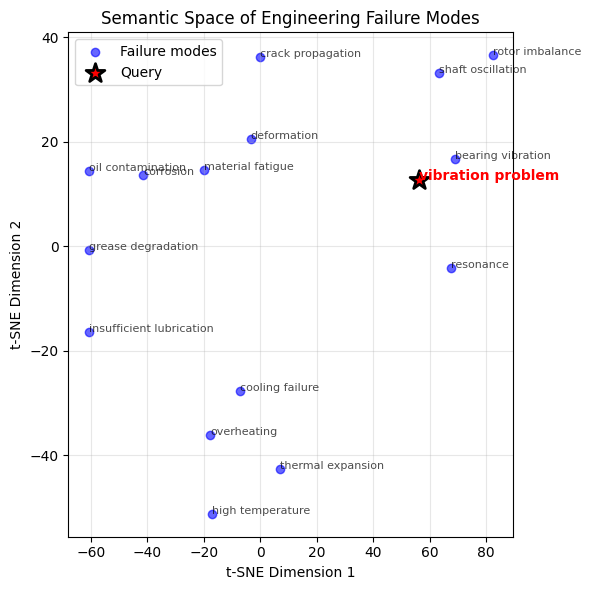

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Engineering failure modes (grouped by type)
terms = [
    # Vibration-related
    "bearing vibration", "shaft oscillation", "rotor imbalance", "resonance",
    # Thermal-related
    "overheating", "high temperature", "thermal expansion", "cooling failure",
    # Lubrication-related
    "oil contamination", "insufficient lubrication", "grease degradation",
    # Structural-related
    "crack propagation", "material fatigue", "corrosion", "deformation"
]

# Query
query = "vibration problem"

# Embed all terms + query
all_texts = terms + [query]
embeddings = model.encode(all_texts, device='cpu')

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords_2d = tsne.fit_transform(embeddings)

# Separate query from terms
term_coords = coords_2d[:-1]
query_coord = coords_2d[-1]

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(term_coords[:, 0], term_coords[:, 1], c='blue', label='Failure modes', alpha=0.6)
plt.scatter(query_coord[0], query_coord[1], c='red', s=200, marker='*', label='Query', edgecolors='black', linewidths=2)

# Annotate points
for i, term in enumerate(terms):
    plt.annotate(term, (term_coords[i, 0], term_coords[i, 1]), fontsize=8, alpha=0.7)
plt.annotate(query, (query_coord[0], query_coord[1]), fontsize=10, fontweight='bold', color='red')

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('Semantic Space of Engineering Failure Modes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Common NLP Tasks

Now that we understand embeddings, let's explore typical NLP tasks that engineers can leverage. Each task addresses a different aspect of text understanding. We'll demonstrate these with simple, practical examples.

### 4.1 Text Classification

**What it is:** Assigning predefined categories or labels to text. For example, classifying customer feedback as positive/negative, or emails as spam/not spam.

**Engineering application:** Categorizing maintenance reports by severity (critical, moderate, minor) or by system affected (electrical, mechanical, hydraulic).

**Simple example:**

In [3]:
from transformers import pipeline

# Zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device="cpu")

# A maintenance log entry
text = "Excessive vibration detected in gearbox housing, possible bearing wear"

# Candidate categories (we just make these up!)
candidate_labels = ["vibration issue", "thermal issue", "lubrication issue", "electrical issue"]

# Classify
result = classifier(text, candidate_labels)

print(f"Text: {text}\n")
for label, score in zip(result["labels"], result["scores"]):
    print(f"{label}: {score:.3f}")


Device set to use cpu


Text: Excessive vibration detected in gearbox housing, possible bearing wear

vibration issue: 0.974
lubrication issue: 0.020
thermal issue: 0.003
electrical issue: 0.002


### 4.2 Named Entity Recognition (NER)

**What it is:** Identifying and extracting specific entities (names, dates, locations, organizations) from text.

**Engineering application:** Extracting component names, part numbers, dates, and measurements from maintenance logs or technical documentation.

**Simple example:**

In [4]:
from flair.data import Sentence
from flair.models import SequenceTagger

# load tagger
tagger = SequenceTagger.load("flair/ner-english-fast")

# make example sentence
sentence = Sentence("George Washington went to Washington")

# predict NER tags
tagger.predict(sentence)

# print sentence
print(sentence)

# print predicted NER spans
print("The following NER tags are found:")
# iterate over entities and print
for entity in sentence.get_spans("ner"):
    print(entity)


2026-01-12 22:19:38,342 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, S-ORG, S-MISC, B-PER, E-PER, S-LOC, B-ORG, E-ORG, I-PER, S-PER, B-MISC, I-MISC, E-MISC, I-ORG, B-LOC, E-LOC, I-LOC, <START>, <STOP>
Sentence[5]: "George Washington went to Washington" → ["George Washington"/PER, "Washington"/LOC]
The following NER tags are found:
Span[0:2]: "George Washington" → PER (0.9972)
Span[4:5]: "Washington" → LOC (0.9834)


### 4.3 Sentiment Analysis

**What it is:** Determining the emotional tone of text (positive, negative, neutral).

**Engineering application:** Analyzing customer complaints to prioritize issues, or gauging technician confidence in repair recommendations ("probably fine" vs "definitely needs replacement").

**Simple example:**

In [7]:
from transformers import pipeline

classifier = pipeline(
    "text-classification", model="Harsha901/tinybert-imdb-sentiment-analysis-model"
)

result = classifier("This movie was absolutely amazing!")
print(result)  # [{'label': 'LABEL_1', 'score': 0.98}]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/57.4M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use mps:0


[{'label': 'positive', 'score': 0.9898097515106201}]


## 5. RAG: Retrieval-Augmented Generation

**Prerequisites:** Before proceeding with this section, ensure you have:
- Ollama installed and running or Groq API Key, saved in `.env` file
- The `gemma3:4b` model pulled (`ollama pull gemma3:4b`)

### 5.1 Basic LLM Interaction with Pydantic AI

Before building a RAG system, let's first understand how to communicate with an LLM using Pydantic AI. This library provides a clean, Pythonic interface for working with language models.

In [9]:
import os
from dotenv import load_dotenv
from pydantic_ai import Agent
import nest_asyncio

# Allow nested event loops in Jupyter
nest_asyncio.apply()

load_dotenv()

os.environ["OLLAMA_BASE_URL"] = "http://127.0.0.1:11434/v1"
# Ollama doesn't require an API key, but pydantic_ai might need it set
os.environ["OLLAMA_API_KEY"] = "ollama"

# ----- WRITE YOUR CODE BELOW THIS LINE -----
agent = Agent(
    "ollama:qwen3:4b",
    instructions="Be concise, reply with one sentence.",
)
# ----- WRITE YOUR CODE ABOVE THIS LINE -----

# Run a simple query
result = agent.run_sync('Where does "hello world" come from?')
print(result.output)



"Hello world" originated as a simple test program in the early 1950s, first used in Fortran to demonstrate basic output functionality.


### 5.2 RAG Concept

**Retrieval-Augmented Generation (RAG)** combines the power of semantic search with LLM generation. The workflow is:

1. **Retrieval**: Given a user query, find the most relevant documents from a knowledge base using embedding similarity
2. **Augmentation**: Add the retrieved documents as context to the prompt
3. **Generation**: The LLM generates an answer grounded in the retrieved facts

**Why RAG matters for engineers:** LLMs have general knowledge but don't know your specific equipment, failures, or procedures. RAG lets you query your organization's maintenance history, technical documents, or design decisions as if talking to an expert who's read everything.

```mermaid
graph LR
    A[User Query] --> B[Embed Query]
    B --> C[Search Knowledge Base]
    C --> D[Retrieve Top-K Docs]
    D --> E[Construct Prompt with Context]
    E --> F[LLM Generate Answer]
    F --> G[Grounded Response]
```

### 5.3 The Knowledge Base: Synthetic Maintenance Logs

For this demonstration, we'll use realistic maintenance logs covering common failure modes. In practice, these could come from your CMMS, technician reports, or historical records.

In [10]:
# Synthetic maintenance logs from a manufacturing facility
logs = [
    "Pump #3 shaft vibration excessive at 8mm/s, bearing replacement recommended",
    "Motor overheating, measured 95°C under normal load, cooling fan obstructed",
    "Gearbox oil contaminated with metal particles, suspect gear wear",
    "Conveyor belt slipping, tension adjustment needed",
    "Hydraulic cylinder leaking from rod seal, seal replacement required",
    "Compressor making loud knocking sound, possible valve failure",
    "Temperature sensor reading 20°C too high, calibration required",
    "Pump cavitation detected, suction line pressure too low",
    "Bearing noise increasing, vibration spectrum shows inner race defect",
    "Control panel display flickering, loose connection in power supply",
    "Lubrication system low pressure, filter clogged",
    "Shaft misalignment detected, coupling wear visible",
    "Cooling system flow reduced, heat exchanger tubes partially blocked",
    "Electrical motor drawing excess current, winding insulation degraded",
    "Pneumatic actuator slow response, air line restriction suspected",
]

print(f"Knowledge base: {len(logs)} maintenance logs")
for i, log in enumerate(logs[:3]):
    print(f"{i + 1}. {log}")
print("...")


Knowledge base: 15 maintenance logs
1. Pump #3 shaft vibration excessive at 8mm/s, bearing replacement recommended
2. Motor overheating, measured 95°C under normal load, cooling fan obstructed
3. Gearbox oil contaminated with metal particles, suspect gear wear
...


### 5.4 Step 1: Embed the Knowledge Base

We'll use sentence-transformers to convert each log into a dense vector representation. These embeddings capture semantic meaning, so similar failures will have similar vectors.

In [11]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed all logs
log_embeddings = model.encode(logs, device='cpu')

print(f"Embedded {len(logs)} logs")
print(f"Each embedding is a vector of shape: {log_embeddings.shape}")
print(f"Example embedding (first 5 dimensions): {log_embeddings[0][:5]}")


Embedded 15 logs
Each embedding is a vector of shape: (15, 384)
Example embedding (first 5 dimensions): [ 0.00474696 -0.04850155  0.01668701 -0.06309661 -0.03421985]


### 5.5 Step 2: Semantic Search (Retrieval)

When a user asks a question, we embed their query and find the most similar logs using cosine similarity.

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# User query
query = "Why is the pump vibrating?"

# Embed the query
query_embedding = model.encode([query])

# Calculate similarity between query and all logs
similarities = cosine_similarity(query_embedding, log_embeddings)[0]

# Get top 3 most relevant logs
top_k = 3
top_indices = np.argsort(similarities)[-top_k:][::-1]

print(f"Query: {query}\n")
print("Top 3 relevant logs:")
for i, idx in enumerate(top_indices, 1):
    print(f"{i}. [Score: {similarities[idx]:.3f}] {logs[idx]}")


Query: Why is the pump vibrating?

Top 3 relevant logs:
1. [Score: 0.525] Pump #3 shaft vibration excessive at 8mm/s, bearing replacement recommended
2. [Score: 0.469] Pump cavitation detected, suction line pressure too low
3. [Score: 0.310] Bearing noise increasing, vibration spectrum shows inner race defect


### 5.6 Step 3: Generate Without Context (Baseline)

First, let's see what happens when we ask the LLM directly, without any retrieved context. The response will be generic and potentially incorrect.

In [13]:
from pydantic_ai import Agent

# Create agent
agent = Agent(
    "ollama:qwen3:4b",
    instructions="You are a maintenance engineer assistant. Answer questions about equipment failures.",
)

# Query without context
query = "Why is the pump vibrating?"
result = agent.run_sync(query)

print("=" * 60)
print("BASELINE (No RAG):")
print("=" * 60)
print(f"Query: {query}")
print(f"Answer: {result.output}")
print("=" * 60)

BASELINE (No RAG):
Query: Why is the pump vibrating?
Answer: 

Pump vibration can occur due to several mechanical or operational factors. Here’s a structured analysis of potential causes and troubleshooting steps:

---

### **1. Mechanical Misalignment**
- **Cause**: Misalignment between the pump and motor shafts.
- **Check**: Use a dial indicator or laser alignment tool to verify alignment. Ensure both shafts are parallel and concentric.

---

### **2. Foundation Issues**
- **Cause**: Uneven, loose, or insufficient foundation.
- **Check**: Ensure the foundation is level, stable, and provides adequate support. Avoid overloading the pump.

---

### **3. Overloading**
- **Cause**: Pump is being operated beyond its design capacity (e.g., high flow rates, pressure, or discharge conditions).
- **Check**: Verify system requirements and ensure the pump is operating within its specified parameters.

---

### **4. Worn Bearings or Seals**
- **Cause**: Worn-out bearings or damaged seals can caus

### 5.7 Step 4: Generate With Context (RAG)

Now we provide the retrieved logs as context. The LLM can ground its answer in actual maintenance history.

In [14]:
# Retrieve relevant logs (from step 5.5)
top_k = 3
top_indices = np.argsort(similarities)[-top_k:][::-1]
relevant_logs = [logs[idx] for idx in top_indices]

# Construct context
context = "\n".join([f"- {log}" for log in relevant_logs])

# Create RAG prompt
rag_prompt = f"""Based on the following maintenance logs, answer the question:

Maintenance Logs:
{context}

Question: {query}

Provide a specific answer based on the logs above."""

# Query with context
result_rag = agent.run_sync(rag_prompt)

print("\n" + "=" * 60)
print("WITH RAG:")
print("=" * 60)
print(f"Query: {query}")
print("\nRetrieved Context:")
for i, log in enumerate(relevant_logs, 1):
    print(f"  {i}. {log}")
print(f"\nAnswer: {result_rag.output}")
print("=" * 60)



WITH RAG:
Query: Why is the pump vibrating?

Retrieved Context:
  1. Pump #3 shaft vibration excessive at 8mm/s, bearing replacement recommended
  2. Pump cavitation detected, suction line pressure too low
  3. Bearing noise increasing, vibration spectrum shows inner race defect

Answer: 

The pump vibration is primarily due to **bearing issues**. Specifically, the logs indicate:  
1. **Excessive shaft vibration (8mm/s)** with a recommendation for **bearing replacement**, and  
2. **Increasing bearing noise** linked to an **inner race defect** in the bearing.  

These issues suggest that the vibration stems from faulty bearings, likely caused by wear or damage to the inner race, rather than cavitation (though cavitation may contribute to vibration in other contexts). The inner race defect directly compromises bearing integrity, leading to abnormal vibrations.


**Resources:**
- Sentence Transformers: https://www.sbert.net/
- Pydantic AI: https://ai.pydantic.dev/
- Hugging Face Transformers: https://huggingface.co/docs/transformers/